In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from unsflow.utils.thesis_plots import set_thesis_style, create_figure

In [2]:
files = [
    '../KT_2.5/results/unstable.pkl',
    '../KT_2.75/results/unstable.pkl',
    '../KT_3.0/results/unstable.pkl',
    '../KT_3.5/results/unstable.pkl',
    '../KT_4.0/results/unstable.pkl',
    '../KT_4.5/results/unstable.pkl',
    '../KT_5.0/results/unstable.pkl',
]

In [3]:
dataset = []
for file in files:
    with open(file, 'rb') as f:
        res = pickle.load(f)
    dataset.append(res)

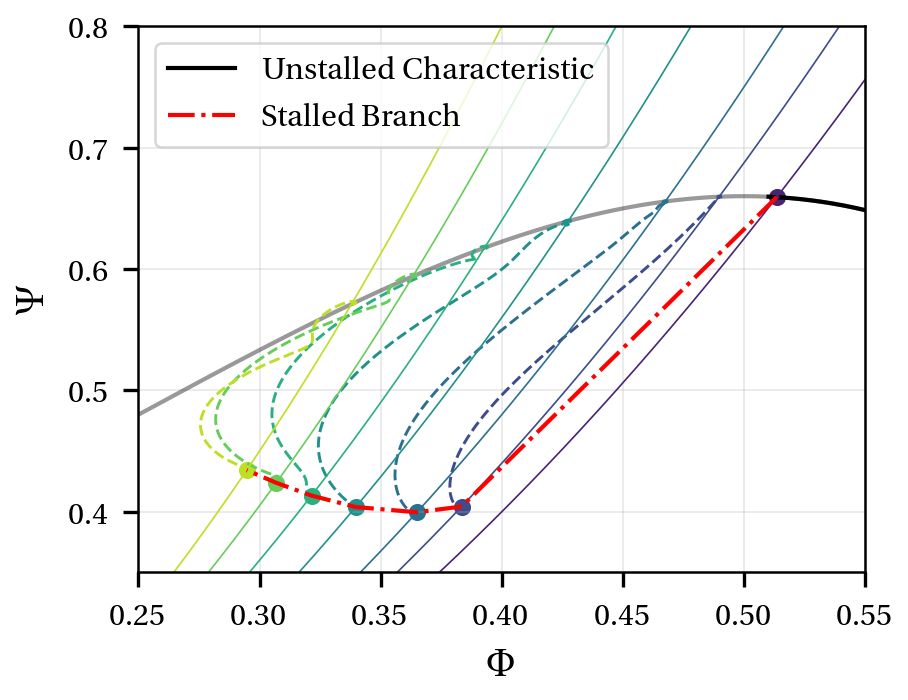

In [21]:
set_thesis_style()
fig, ax = create_figure(fraction=0.6, aspect_ratio=1.3, subplots=(1, 1))

xp, yp = [], []
cmap = plt.get_cmap('viridis')
colors = np.linspace(0.1, 0.9, len(dataset))
for ii,data in enumerate(dataset):
    phi = data.phi
    psi_c = data.psi_c
    psi_v = data.psi_v
    sol = data.solutionMooreGreitzer
    
    if ii==0:
        ax.plot(phi[phi>0.51], psi_c[phi>0.51], label='Unstalled Characteristic', color='k')
        ax.plot(phi, psi_c, '-k', alpha=0.4)
    ax.plot(phi, psi_v, '-', lw=0.4, c=cmap(colors[ii]), alpha=1.0)
    ax.plot(sol[:,1], sol[:,0], '--', color=cmap(colors[ii]), lw=0.7)
    ax.scatter(sol[-1,1], sol[-1,0], color=cmap(colors[ii]))
    
    xp.append(sol[-1,1])
    yp.append(sol[-1,0])

ax.plot(xp, yp, '-.r', label='Stalled Branch')


ax.set_xlabel(r'$\Phi$')
ax.set_ylabel(r'$\Psi$')
ax.legend()
# plt.tight_layout()
ax.grid(alpha=0.3)
ax.set_xlim([0.25,0.55])
ax.set_ylim([0.35,0.8])
fig.savefig('mooreGreitzer_trajectory_B_05_stalled_char.pdf')
    
